In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, f1_score
import timm  # ConvNeXt V2 모델을 불러오기 위한 라이브러리
import copy
import os

# [1] 장치 설정 (3070 Ti 활용)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 사용 중인 장치: {device}")

# [2] 데이터 전처리
# ConvNeXt V2는 224x224 해상도와 ImageNet 정규화 값을 기본으로 사용합니다.
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # 학습 성능 향상을 위한 증강 추가
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 데이터 경로 설정
data_dir = r'C:\Users\한민규\Desktop\머신러닝 실습\03_ConvNEXT_V2\data\Flowers30'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms)

# [3] 데이터 3분할 (Train 70%, Val 15%, Test 15%)
full_size = len(full_dataset)
train_size = int(0.7 * full_size)
val_size = int(0.15 * full_size)
test_size = full_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) # 통계적 재현성
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"📊 데이터 분할 완료: Train({train_size}), Val({val_size}), Test({test_size})")

# [4] ConvNeXt V2 모델 설정
# 'convnextv2_atto'는 논문에서 제안된 FCMAE 방식으로 사전 학습된 매우 가벼운 모델입니다.
model = timm.create_model('convnextv2_atto', pretrained=True, num_classes=30)
model = model.to(device)

# [5] 손실 함수 및 최적화 설정
criterion = nn.CrossEntropyLoss()
# ConvNeXt V2 논문에서는 AdamW와 특정 Weight Decay 값을 권장합니다.
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

# [6] 학습 및 검증 함수
def train_model(num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            all_labels, all_preds = [], []

            for inputs, labels in (train_loader if phase == 'train' else val_loader):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            epoch_loss = running_loss / (len(train_dataset) if phase == 'train' else len(val_dataset))
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
            
            if phase == 'train': train_losses.append(epoch_loss)
            else: val_losses.append(epoch_loss)

            print(f'{phase} Loss: {epoch_loss:.4f} F1-Score: {epoch_f1:.4f}')

            # 가장 좋은 모델 저장 (Validation F1-Score 기준)
            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return train_losses, val_losses

# [7] 실행 및 저장
train_losses, val_losses = train_model(num_epochs=10)
torch.save(model.state_dict(), 'flower30_convnextv2_atto.pth')
print("✅ ConvNeXt V2 모델 학습 완료 및 저장!")

# [8] 최종 테스트 (Test Set 평가)
print("\n🔥 최종 Test Set 평가 시작...")
model.eval()
test_labels, test_preds = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())

print("\n--- ConvNeXt V2 최종 결과 보고서 (Test Set) ---")
print(classification_report(test_labels, test_preds, target_names=full_dataset.classes))

c:\Users\한민규\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 사용 중인 장치: cuda
📊 데이터 분할 완료: Train(7548), Val(1617), Test(1619)


Epoch 0/9
train Loss: 1.4168 F1-Score: 0.6269
val Loss: 0.7428 F1-Score: 0.8048
Epoch 1/9
train Loss: 0.4884 F1-Score: 0.8754
val Loss: 0.4964 F1-Score: 0.8644
Epoch 2/9
train Loss: 0.2024 F1-Score: 0.9562
val Loss: 0.4123 F1-Score: 0.8918
Epoch 3/9
train Loss: 0.0811 F1-Score: 0.9841
val Loss: 0.3596 F1-Score: 0.9066
Epoch 4/9
train Loss: 0.0345 F1-Score: 0.9958
val Loss: 0.3483 F1-Score: 0.9153
Epoch 5/9
train Loss: 0.0175 F1-Score: 0.9979
val Loss: 0.3691 F1-Score: 0.9077
Epoch 6/9
train Loss: 0.0483 F1-Score: 0.9887
val Loss: 0.4403 F1-Score: 0.8827
Epoch 7/9
train Loss: 0.0655 F1-Score: 0.9830
val Loss: 0.4992 F1-Score: 0.8815
Epoch 8/9
train Loss: 0.0550 F1-Score: 0.9869
val Loss: 0.4120 F1-Score: 0.8961
Epoch 9/9
train Loss: 0.0278 F1-Score: 0.9938
val Loss: 0.3897 F1-Score: 0.9036
✅ ConvNeXt V2 모델 학습 완료 및 저장!

🔥 최종 Test Set 평가 시작...

--- ConvNeXt V2 최종 결과 보고서 (Test Set) ---
               precision    recall  f1-score   support

       Acacia       0.73      0.98      0.84     

✅ 사용 중인 장치: cuda


C:\Users\한민규\AppData\Local\Temp\ipykernel_24276\3163173138.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


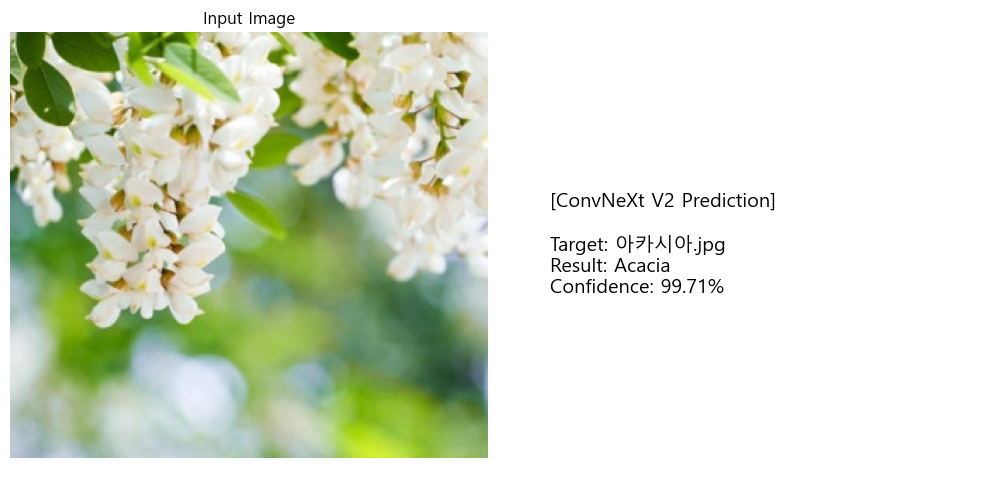

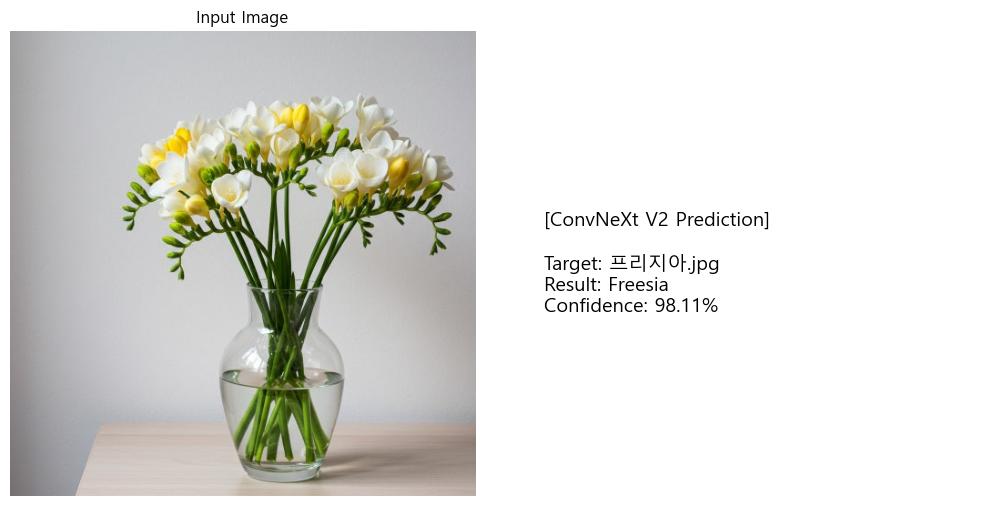

In [6]:
import torch
import torch.nn as nn
from torchvision import transforms
import timm
from PIL import Image
import matplotlib.pyplot as plt
import os

# Matplotlib 한글 폰트 설정 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# [1] 장치 설정 (3070 Ti 가속)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 사용 중인 장치: {device}")

# [2] ConvNeXt V2 모델 로드 함수
def load_convnext_v2(model_path, num_classes=30):
    # timm을 사용하여 아키텍처 생성 (학습 시 사용한 'atto' 모델)
    model = timm.create_model('convnextv2_atto', pretrained=False)
    
    # 클래스 수에 맞게 헤드 수정
    model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)
    
    # 가중치 로드
    model.load_state_dict(torch.load(model_path))
    model = model.to(device).eval()
    
    return model

# [3] 이미지 전처리 설정 (ConvNeXt V2 권장값)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# [4] 단일 모델 예측 및 시각화 함수
def predict_convnext(image_path, model, class_names):
    if not os.path.exists(image_path):
        print(f"❌ 파일을 찾을 수 없습니다: {image_path}")
        return

    # 이미지 불러오기 및 변환
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        # 추론 수행
        logits = model(img_tensor)
        probs = torch.nn.functional.softmax(logits, dim=1)
        conf, pred = torch.max(probs, 1)

    # 시각화
    plt.figure(figsize=(10, 5))
    
    # 1. 원본 이미지 출력
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')

    # 2. 예측 결과 출력
    result_text = (
        f"[ConvNeXt V2 Prediction]\n\n"
        f"Target: {os.path.basename(image_path)}\n"
        f"Result: {class_names[pred[0]]}\n"
        f"Confidence: {conf[0]*100:.2f}%"
    )
    
    plt.subplot(1, 2, 2)
    plt.text(0.1, 0.5, result_text, fontsize=14, verticalalignment='center')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# [5] 실제 실행 부분
class_names = full_dataset.classes

# 모델 파일 경로
CONVNEXT_PATH = 'flower30_convnextv2_atto.pth'

# 모델 불러오기
convnext_model = load_convnext_v2(CONVNEXT_PATH)

# 검증하고 싶은 이미지 경로 리스트
test_images = [
    r'C:\Users\한민규\Desktop\머신러닝 실습\03_ConvNEXT_V2\data\아카시아.jpg',
    r'C:\Users\한민규\Desktop\머신러닝 실습\03_ConvNEXT_V2\data\프리지아.jpg'
]

# 실행
for img_path in test_images:
    predict_convnext(img_path, convnext_model, class_names)

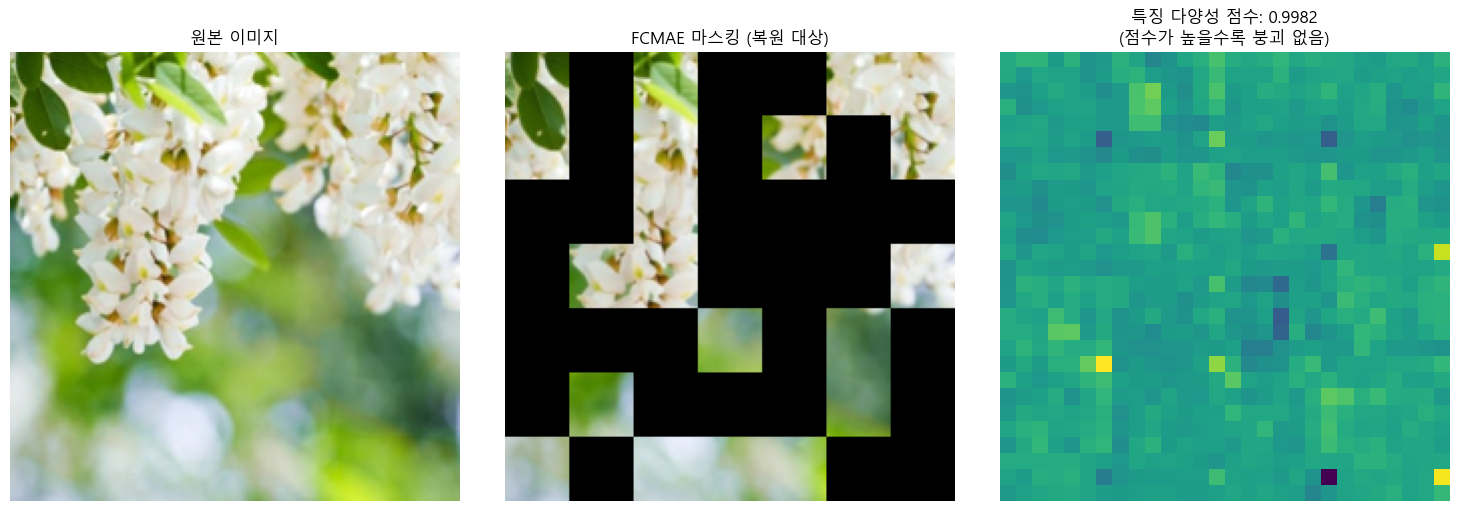

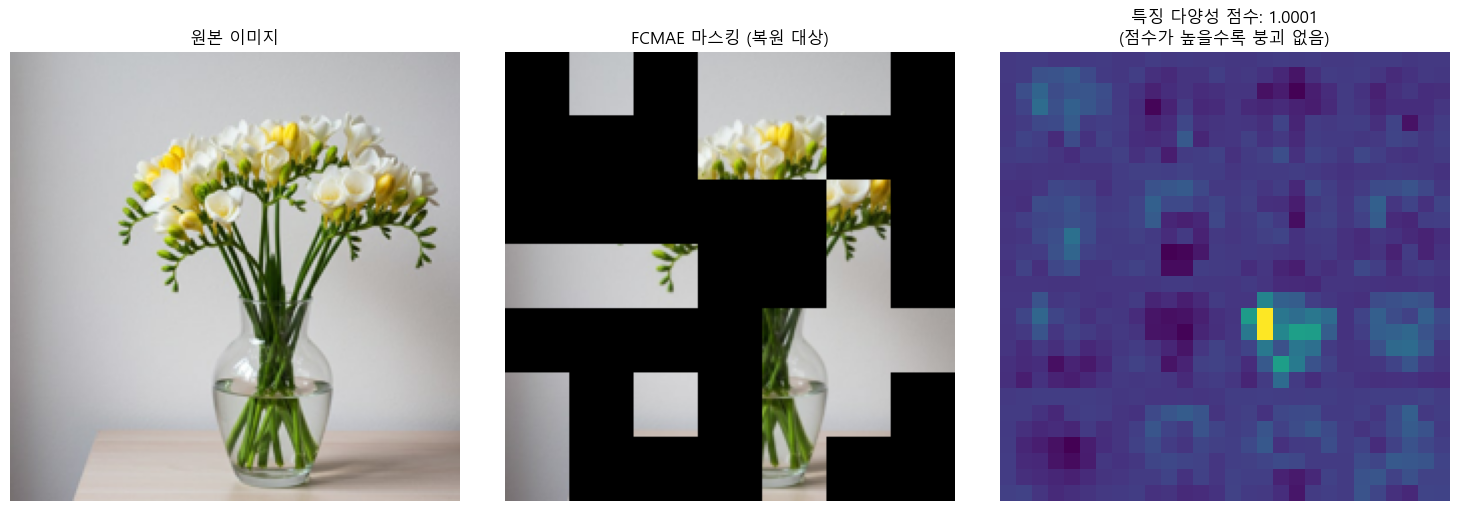

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import timm

# [1] 한글 깨짐 방지 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# [2] FCMAE 스타일 마스킹 함수 구현
def apply_fcmae_mask(image_tensor, patch_size=32, mask_ratio=0.6):
    """
    이미지를 패치 단위로 나누고 무작위로 마스킹합니다.
    """
    B, C, H, W = image_tensor.shape
    h_patches, w_patches = H // patch_size, W // patch_size
    num_patches = h_patches * w_patches
    num_mask = int(mask_ratio * num_patches)
    
    # 랜덤 마스크 생성
    mask = torch.zeros(num_patches)
    mask[:num_mask] = 1
    mask = mask[torch.randperm(num_patches)].reshape(1, 1, h_patches, w_patches)
    
    # 패치 크기만큼 확장 (Upsample)
    mask = torch.nn.functional.interpolate(mask, size=(H, W), mode='nearest')
    masked_image = image_tensor * (1 - mask.to(image_tensor.device))
    
    return masked_image, mask

# [3] 특징 붕괴(Feature Collapse) 확인을 위한 코사인 거리 계산 함수
def calculate_feature_diversity(features):
    """
    채널 간 코사인 거리를 계산하여 특징 다양성을 측정합니다.
    값이 클수록(0.5에 가까울수록) 붕괴가 일어나지 않은 상태입니다.
    """
    # features shape: [1, C, H, W] -> [C, H*W]
    c = features.shape[1]
    f = features.view(c, -1)
    
    # 코사인 유사도 계산
    f_norm = f / (f.norm(dim=1, keepdim=True) + 1e-8)
    cos_sim = torch.mm(f_norm, f_norm.t()) # [C, C]
    
    # 코사인 거리 = 1 - 유사도 (자기 자신과의 관계 제외)
    dist = 1 - cos_sim
    off_diag = dist[~torch.eye(c, dtype=bool)]
    return off_diag.mean().item()

# [4] 메인 시각화 실행
def visualize_convnext_v2_logic(img_path):
    # 1. 이미지 로드 및 전처리
    img = Image.open(img_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    img_tensor = preprocess(img).unsqueeze(0)

    # 2. FCMAE 마스킹 적용 (60% 가림)
    masked_img_tensor, _ = apply_fcmae_mask(img_tensor, patch_size=32, mask_ratio=0.6)
    masked_img = transforms.ToPILImage()(masked_img_tensor.squeeze(0))

    # 3. 모델 로드 및 중간 특징 추출 (ConvNeXt V2 Atto)
    # GRN이 포함된 V2 모델은 특징 붕괴가 해결된 상태입니다.
    model = timm.create_model('convnextv2_atto', pretrained=True).eval()
    
    with torch.no_grad():
        # 첫 번째 스테이지의 특징 추출
        features = model.forward_features(img_tensor)
        
    # 4. 특징 다양성 점수 계산 (논문의 Figure 3 지표)
    diversity_score = calculate_feature_diversity(features)

    # 5. 결과 시각화
    plt.figure(figsize=(15, 5))

    # (1) 원본 vs 마스킹 (FCMAE 방식)
    plt.subplot(1, 3, 1)
    plt.imshow(img.resize((224, 224)))
    plt.title("원본 이미지")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(masked_img)
    plt.title("FCMAE 마스킹 (복원 대상)")
    plt.axis('off')

    # (2) 채널별 활성화 맵 시각화 (특징 붕괴 여부 시각적 확인)
    # 64개의 채널 중 상위 16개만 출력
    act_map = features[0, :16].cpu().numpy()
    plt.subplot(1, 3, 3)
    grid_act = np.vstack([np.hstack(act_map[i:i+4]) for i in range(0, 16, 4)])
    plt.imshow(grid_act, cmap='viridis')
    plt.title(f"특징 다양성 점수: {diversity_score:.4f}\n(점수가 높을수록 붕괴 없음)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# 실행 (이미지 경로를 본인 환경에 맞게 수정하세요)
visualize_convnext_v2_logic(r'C:\Users\한민규\Desktop\머신러닝 실습\03_ConvNEXT_V2\data\아카시아.jpg')
visualize_convnext_v2_logic(r'C:\Users\한민규\Desktop\머신러닝 실습\03_ConvNEXT_V2\data\프리지아.jpg')